In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


(vectorization)=
# Vectorization

The [JAX documentation](https://docs.jax.dev/en/latest/101/arrays.html) covers the array basics in more detail. JAX provides NumPy-like arrays and functions that support automatic differentiation and compilation.
Ordinary JAX arrays are immutable. Indexed assignment such as `x[i] = y` is therefore invalid, while `x += y` creates a new array and rebinds `x` instead of mutating the original array. Indexed updates use the functional form `x = x.at[i].set(y)`. This functional interface allows JAX to transform and compile computations predictably.

Vectorization lifts a function that acts on one input so that it acts on a batch of inputs. The resulting code is concise and can often be compiled more efficiently. We use radial basis functions as a running example. A weighted radial-basis model has the form

$$
f(x) = \sum_{i=1}^n w_i \phi_i(x)
$$

where

$$
\phi_i(x) = \exp\left(-\frac{\lVert x-c_i\rVert_2^2}{2\sigma^2}\right).
$$

Here $c_i$ is the center and $\sigma>0$ is the bandwidth. This section focuses on evaluating the feature functions $\phi_i$ over many centers and inputs; it does not fit the weights $w_i$. In the code, `sigma2` denotes $\sigma^2$.

We begin with the radial basis function for one input and one center:

In [3]:
import jax.numpy as jnp

rbf = lambda x, c, sigma2: jnp.exp(-jnp.sum((x - c) ** 2, axis=-1) / (2.0 * sigma2))

Let's demonstrate it in 1D:

In [4]:
x = jnp.array([0.5])
c = jnp.array([0.0])
sigma2 = 0.1

rbf(x, c, sigma2)

Array(0.2865048, dtype=float32)

Now we would like to vectorize it with respect to the input $c_i$ so that we can pass all the centers at once.
We can do this by using the [`vmap`](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html) function:

In [5]:
from jax import vmap

phi = vmap(rbf, in_axes=(None, 0, None), out_axes=0)

What just happened here? First, let's use it:

In [6]:
centers = jnp.linspace(-1, 1, 10)
phi(x, centers, sigma2)

Array([1.3007298e-05, 2.8484085e-04, 3.8067168e-03, 3.1047985e-02,
       1.5454279e-01, 4.6945971e-01, 8.7032479e-01, 9.8468637e-01,
       6.7990482e-01, 2.8650481e-01], dtype=float32)

Let's break down how we called `vmap`:

- The first argument is just the function we want to vectorize.
- The second argument, `in_axes`, is a description of how we want to vectorize the function. The function has three inputs. So we pass a tuple with three elements. The first element is `None` because we don't want to vectorize with respect to the first input, `x`. Same with the third element. The second element is `0` because we want to vectorize with respect to the second input, `c`. The `0` here means that we want to vectorize with respect to the first dimension of `c`. Wait a second. Does that mean that our code works with 2D arrays? Yes indeed!
- The third argument of `vmap` is `out_axes`. This is a description of how we want to vectorize the output of the function. The output of the function is a scalar. So we pass `0` to indicate that we want to vectorize with respect to the first dimension of the output.

In [7]:
# We will try it on this x:
x_2d = jnp.array([0.5, 0.7])

# Here are the 2D centers:
c1 = jnp.linspace(-1, 1, 10)
c2 = jnp.linspace(-1, 1, 10)
C = jnp.meshgrid(c1, c2)
centers = jnp.stack(C, axis=-1).reshape(-1, 2)
centers 

Array([[-1.        , -1.        ],
       [-0.7777778 , -1.        ],
       [-0.5555556 , -1.        ],
       [-0.33333328, -1.        ],
       [-0.11111113, -1.        ],
       [ 0.11111114, -1.        ],
       [ 0.33333337, -1.        ],
       [ 0.5555556 , -1.        ],
       [ 0.7777778 , -1.        ],
       [ 1.        , -1.        ],
       [-1.        , -0.7777778 ],
       [-0.7777778 , -0.7777778 ],
       [-0.5555556 , -0.7777778 ],
       [-0.33333328, -0.7777778 ],
       [-0.11111113, -0.7777778 ],
       [ 0.11111114, -0.7777778 ],
       [ 0.33333337, -0.7777778 ],
       [ 0.5555556 , -0.7777778 ],
       [ 0.7777778 , -0.7777778 ],
       [ 1.        , -0.7777778 ],
       [-1.        , -0.5555556 ],
       [-0.7777778 , -0.5555556 ],
       [-0.5555556 , -0.5555556 ],
       [-0.33333328, -0.5555556 ],
       [-0.11111113, -0.5555556 ],
       [ 0.11111114, -0.5555556 ],
       [ 0.33333337, -0.5555556 ],
       [ 0.5555556 , -0.5555556 ],
       [ 0.7777778 ,

Here we go:

In [8]:
phi(x_2d, centers, sigma2)

Array([6.89654367e-12, 1.51024249e-10, 2.01834394e-09, 1.64618186e-08,
       8.19394259e-08, 2.48910140e-07, 4.61451378e-07, 5.22086680e-07,
       3.60489139e-07, 1.51906477e-07, 2.35541475e-10, 5.15800469e-09,
       6.89334883e-08, 5.62229616e-07, 2.79852247e-06, 8.50115794e-06,
       1.57601899e-05, 1.78310984e-05, 1.23119853e-05, 5.18814613e-06,
       4.90947327e-09, 1.07510104e-07, 1.43680620e-06, 1.17187374e-05,
       5.83305882e-05, 1.77192778e-04, 3.28495167e-04, 3.71659669e-04,
       2.56623025e-04, 1.08138243e-04, 6.24507166e-08, 1.36757831e-06,
       1.82768235e-05, 1.49067622e-04, 7.41991331e-04, 2.25397199e-03,
       4.17860644e-03, 4.72767837e-03, 3.26436060e-03, 1.37556787e-03,
       4.84810926e-07, 1.06166626e-05, 1.41885001e-04, 1.15722849e-03,
       5.76015608e-03, 1.74978171e-02, 3.24389637e-02, 3.67014743e-02,
       2.53415871e-02, 1.06786806e-02, 2.29689908e-06, 5.02987386e-05,
       6.72210939e-04, 5.48262103e-03, 2.72900127e-02, 8.28997865e-02,
      

Now, let's also vectorize this with respect to the first input, `x`:

In [9]:
vphi = vmap(phi, in_axes=(0, None, None), out_axes=0)

In [10]:
xs = jnp.linspace(-1, 1, 100).reshape(-1, 1)
cs = jnp.linspace(-1, 1, 5).reshape(-1, 1)
phis = vphi(xs, cs, sigma2)
print(phis.shape)

(100, 5)


Let's plot them:

array([<Axes: title={'center': 'RBF features'}, xlabel='x', ylabel='phi(x, c)'>],
      dtype=object)

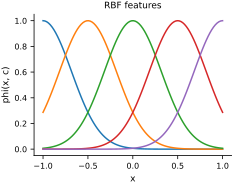

In [11]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(xs, phis)
ax.set(xlabel="x", ylabel="phi(x, c)", title="RBF features")
finalize_axes(keep_box=False)

And the same code also works on 2D. Here are some grid points:

In [12]:
x1 = jnp.linspace(-1, 1, 50)
x2 = jnp.linspace(-1, 1, 50)
X1, X2 = jnp.meshgrid(x1, x2)
X = jnp.stack((X1, X2), axis=-1).reshape(-1, 2)
X.shape

(2500, 2)

We will evaluate on the centers we constructed previously:

In [13]:
centers.shape

(100, 2)

Here are all the basis functions on these points:

In [14]:
phis = vphi(X, centers, sigma2)
phis.shape

(2500, 100)

Let's do the contour of one of them:

array([<Axes: title={'center': 'RBF feature 25'}, xlabel='x1', ylabel='x2'>,
       <Axes: label='<colorbar>'>], dtype=object)

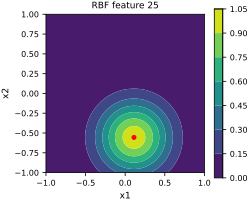

In [15]:
i = 25
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"])
ax.set_aspect("equal")
c = ax.contourf(X1, X2, phis[:, i].reshape(50, 50))
ax.plot(centers[i, 0], centers[i, 1], "ro")
ax.set(xlabel="x1", ylabel="x2", title=f"RBF feature {i}")
plt.colorbar(c)
finalize_axes(keep_box=True)

The same function now handles one- and two-dimensional points. `vmap` introduces the batch axes without an explicit Python loop, and `jax.jit` can compile the batched computation.

The same transformations can be stacked with decorators:

In [16]:
from jax import jit
import functools as ft

@jit
@ft.partial(vmap, in_axes=(0, None, None), out_axes=0)
@ft.partial(vmap, in_axes=(None, 0, None), out_axes=0)
def rbf_basis(x, c, sigma2):
    return jnp.exp(-jnp.sum((x - c) ** 2, axis=-1) / (2.0 * sigma2))

In [17]:
rbf_basis(X, centers, sigma2).shape

(2500, 100)

Compare the time it takes to run the function with and without `jit`.
Here is without `jit`:

In [18]:
%timeit vphi(X, centers, sigma2).block_until_ready()

790 μs ± 357 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Here is with `jit`:

In [19]:
%timeit rbf_basis(X, centers, sigma2).block_until_ready()

271 μs ± 17.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
